In [ ]:
from kan import KAN
import torch
from torch import nn
import numpy as np
import random

RMSE after KAN initialization: 0.0011575428070500493


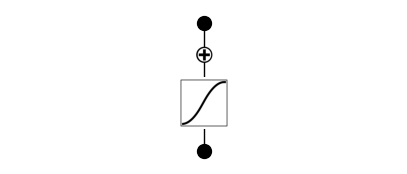

In [14]:
seed = 10
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()

device = 'cpu'
targetModel = nn.Sigmoid()
X = torch.randn(1000, 1).to(device)
y_true = targetModel(X).to(device)
kan = KAN(width=[1,1], seed=seed, grid=3, auto_save=False, symbolic_enabled=False)
kan.set_splines_MLP(X, [[targetModel]])
y_pred = kan(X)
print("RMSE after KAN initialization:", rmse(y_true, y_pred))
kan.plot(beta=100)


In [35]:
rmseSigmoid = []
rmseReLU = []
rmseSELU = []
rmseTanh = []
grid = 3
for i in range(100):
    print(i)
    seed = i
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    X = torch.randn(1000, 1).to(device)

    sigmoid = nn.Sigmoid()
    relu = nn.ReLU()
    selu = nn.SELU()
    tanh = nn.Tanh()

    y_sigmoid = sigmoid(X)
    y_relu = relu(X)
    y_selu = selu(X)
    y_tanh = tanh(X)

    kan1 = KAN(width=[1,1], seed=seed, grid=grid, auto_save=False, symbolic_enabled=False)
    kan1.set_splines_MLP(X, [[sigmoid]])
    y_kan_sigmoid = kan1(X)
    rmseSigmoid.append(rmse(y_sigmoid, y_kan_sigmoid))

    kan2 = KAN(width=[1,1], seed=seed, grid=grid, auto_save=False, symbolic_enabled=False)
    kan2.set_splines_MLP(X, [[relu]])
    y_kan_relu = kan2(X)
    rmseReLU.append(rmse(y_relu, y_kan_relu))

    kan3 = KAN(width=[1,1], seed=seed, grid=grid, auto_save=False, symbolic_enabled=False)
    kan3.set_splines_MLP(X, [[selu]])
    y_kan_selu = kan3(X)
    rmseSELU.append(rmse(y_selu, y_kan_selu))

    kan4 = KAN(width=[1,1], seed=seed, grid=grid, auto_save=False, symbolic_enabled=False)
    kan4.set_splines_MLP(X, [[tanh]])
    y_kan_tanh = kan4(X)
    rmseTanh.append(rmse(y_tanh, y_kan_tanh))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


C:\Users\maart\AppData\Local\Temp\ipykernel_7096\240534560.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rmseSigmoid, rmseReLU, rmseSELU, rmseTanh],


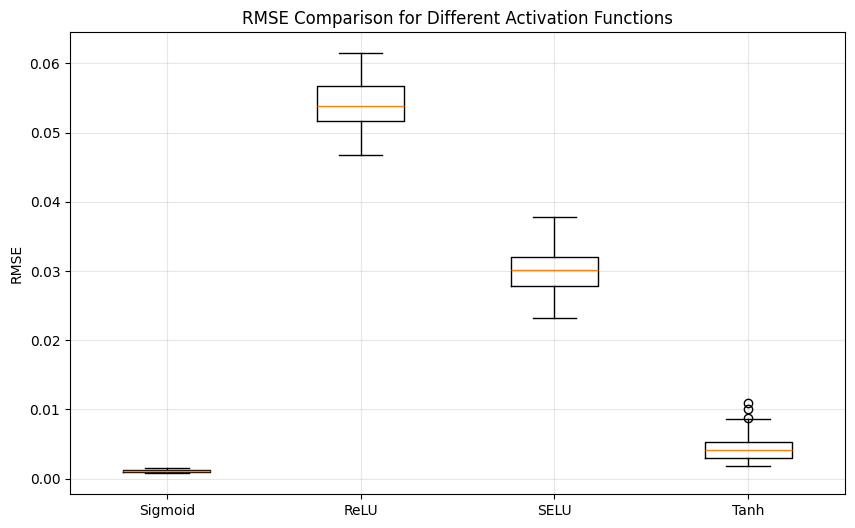

In [36]:
import matplotlib.pyplot as plt

# Create boxplots for the RMSE lists
plt.figure(figsize=(10, 6))
plt.boxplot([rmseSigmoid, rmseReLU, rmseSELU, rmseTanh], 
            labels=['Sigmoid', 'ReLU', 'SELU', 'Tanh'])
plt.ylabel('RMSE')
plt.title('RMSE Comparison for Different Activation Functions')
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
print(rmseSigmoid)

[0.0014458788791671395, 0.0013920451747253537, 0.0011381885269656777, 0.0012914416147395968, 0.001138998894020915, 0.0011616881238296628, 0.001153604593127966, 0.0010883045615628362, 0.0010450129630044103, 0.0009739308734424412, 0.0011575428070500493, 0.0009380578994750977, 0.0007812781841494143, 0.0009328615269623697, 0.0013791302917525172, 0.0009465202456340194, 0.0009409600170329213, 0.0011347777908667922, 0.0014478048542514443, 0.0014891476603224874, 0.0009426081669516861, 0.0008095848024822772, 0.0010141631355509162, 0.0010609549935907125, 0.0009700863738544285, 0.001100720139220357, 0.0015099677257239819, 0.0008610574877820909, 0.0013847012305632234, 0.001221851329319179, 0.0009003486484289169, 0.001421213848516345, 0.0013076233444735408, 0.0012487194035202265, 0.000954969902522862, 0.0013701192801818252, 0.0010328612988814712, 0.0014106626622378826, 0.001473554060794413, 0.0011304424842819571, 0.0010002079652622342, 0.0013967114500701427, 0.0009429613710381091, 0.000768753467127